In [1]:
import urllib.request
import os

# 1. 將類別與想要存放的資料夾名稱綁定成一個字典
dataset_groups = {
    "Group_A": ['airplane', 'apple', 'dog', 't-shirt', 'star'],  # 差異大
    "Group_B": ['clock', 'compass', 'wheel', 'donut', 'pizza']   # 差異小
}

base_url = 'https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/'

print("📥 開始自動分類下載 QuickDraw 資料集...")

# 2. 針對每一組進行迴圈處理
for folder_name, categories in dataset_groups.items():
    # os.makedirs 可以建立資料夾，exist_ok=True 代表如果資料夾已經存在就不會報錯
    os.makedirs(folder_name, exist_ok=True)
    print(f"\n📁 進入資料夾: {folder_name}/")
    
    for category in categories:
        url = base_url + category.replace('_', '%20') + '.npy'
        
        # os.path.join 會自動幫你組合路徑，例如 "Group_A/dog.npy"
        file_path = os.path.join(folder_name, f"{category}.npy")
        
        if not os.path.exists(file_path):
            print(f"  -- 正在下載 {category}...")
            urllib.request.urlretrieve(url, file_path)
            print(f"  ✅ {category} 下載完成！")
        else:
            print(f"  ⏩ {category} 已經存在，跳過。")

print("\n🎉 所有資料皆已分類下載完畢！")

📥 開始自動分類下載 QuickDraw 資料集...

📁 進入資料夾: Group_A/
  -- 正在下載 airplane...
  ✅ airplane 下載完成！
  -- 正在下載 apple...
  ✅ apple 下載完成！
  -- 正在下載 dog...
  ✅ dog 下載完成！
  -- 正在下載 t-shirt...
  ✅ t-shirt 下載完成！
  -- 正在下載 star...
  ✅ star 下載完成！

📁 進入資料夾: Group_B/
  -- 正在下載 clock...
  ✅ clock 下載完成！
  -- 正在下載 compass...
  ✅ compass 下載完成！
  -- 正在下載 wheel...
  ✅ wheel 下載完成！
  -- 正在下載 donut...
  ✅ donut 下載完成！
  -- 正在下載 pizza...
  ✅ pizza 下載完成！

🎉 所有資料皆已分類下載完畢！


環境完美運作，沒有任何 DLL 錯誤！


In [3]:
import sys
!{sys.executable} -m pip install scikit-learn numpy matplotlib

  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 2.4 MB/s eta 0:00:04
   ----- ---------------------------------- 1.0/8.3 MB 2.3 MB/s eta 0:00:04
   ------ --------------------------------- 1.3/8.3 MB 2.3 MB/s eta 0:00:04
   -------- ------------------------------- 1.8/8.3 MB 2.0 MB/s eta 0:00:04
   ---------- ----------------------------- 2.1/8.3 MB 1.9 MB/s eta 0:00:04
   ----------- ---------------------------- 2.4/8.3 MB 1.9 MB/s eta 0:00:04
   ------------ --------------------------- 2.6/8.3 MB 1.8 MB/s eta 0:00:04
   --------------- ------------------------ 3.1/8.3 MB 1.8


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import sklearn
import numpy as np
import matplotlib.pyplot as plt

print(f"Scikit-Learn 版本: {sklearn.__version__}")
print("環境建置大成功！")

ImportError: DLL load failed while importing _openmp_helpers: 應用程式控制原則已封鎖此檔案。

In [6]:
import sklearn
import numpy as np
import matplotlib.pyplot as plt
print("環境完美運作，沒有任何 DLL 錯誤！")

環境完美運作，沒有任何 DLL 錯誤！


In [3]:
import numpy as np
import os
from sklearn.model_selection import train_test_split

def load_and_preprocess_data(categories, folder_name, max_per_class=1000):
    X_list, y_list = [], []
    print(f"🔍 開始從 {folder_name}/ 載入並處理資料...")
    
    for label_id, category in enumerate(categories):
        # 組合出正確的檔案路徑，例如 "Group_A/airplane.npy"
        file_path = os.path.join(folder_name, f"{category}.npy")
        
        # 檢查檔案是否存在，避免報錯
        if os.path.exists(file_path):
            data = np.load(file_path)[:max_per_class]
            X_list.append(data)
            y_list.append(np.full(len(data), label_id))
        else:
            print(f"⚠️ 找不到檔案: {file_path}，請確認下載步驟是否完成。")
            
    # 將所有類別合併
    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)
    
    # 影像正規化 (0~255 轉換為 0~1)，這對神經網路收斂極度重要
    X = X.astype('float32') / 255.0
    
    # 切分訓練集 (80%) 與測試集 (20%)，並使用 stratify 保持類別平衡
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"✅ {folder_name} 處理完成！訓練集形狀: {X_train.shape}, 測試集形狀: {X_test.shape}\n")
    return X_train, X_test, y_train, y_test

# 1. 定義我們的兩組挑戰名單
GROUP_A = ['airplane', 'apple', 'dog', 't-shirt', 'star']
GROUP_B = ['clock', 'compass', 'wheel', 'donut', 'pizza']

# 2. 執行讀取函數
X_train_A, X_test_A, y_train_A, y_test_A = load_and_preprocess_data(GROUP_A, "Group_A")
X_train_B, X_test_B, y_train_B, y_test_B = load_and_preprocess_data(GROUP_B, "Group_B")

🔍 開始從 Group_A/ 載入並處理資料...
✅ Group_A 處理完成！訓練集形狀: (4000, 784), 測試集形狀: (1000, 784)

🔍 開始從 Group_B/ 載入並處理資料...
✅ Group_B 處理完成！訓練集形狀: (4000, 784), 測試集形狀: (1000, 784)



🚀 開始進行 Group A vs Group B 的模型大亂鬥！(神經網路需要較多時間，請耐心等候)

========== 正在測試 Group A (差異度大) ==========
[Logistic Regression (線性)] 準確度: 0.7420 | 耗時: 1.22 秒
[Random Forest (樹狀)] 準確度: 0.8570 | 耗時: 2.05 秒
[Neural Network (神經網路)] 準確度: 0.8520 | 耗時: 1.26 秒
-------------------------------------------------------
========== 正在測試 Group B (差異度小) ==========
[Logistic Regression (線性)] 準確度: 0.5620 | 耗時: 4.10 秒
[Random Forest (樹狀)] 準確度: 0.7120 | 耗時: 2.40 秒
[Neural Network (神經網路)] 準確度: 0.6970 | 耗時: 1.49 秒
-------------------------------------------------------


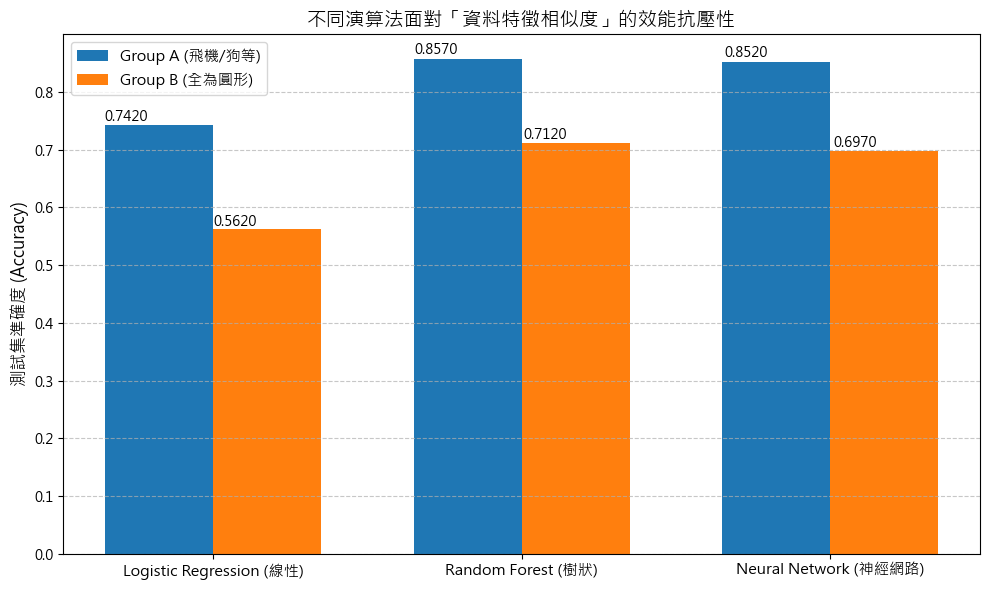

In [4]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# 1. 打包兩組資料以利迴圈處理 (名稱已統一)
datasets = {
    "Group A (差異度大)": (X_train_A, X_test_A, y_train_A, y_test_A),
    "Group B (差異度小)": (X_train_B, X_test_B, y_train_B, y_test_B)
}

# 2. 準備三種不同原理的模型
models = {
    "Logistic Regression (線性)": LogisticRegression(max_iter=500, C=1.0),
    "Random Forest (樹狀)": RandomForestClassifier(n_estimators=100, random_state=42),
    "Neural Network (神經網路)": MLPClassifier(
        hidden_layer_sizes=(128, 64), 
        activation='relu', 
        solver='adam', 
        max_iter=500, 
        early_stopping=True, 
        random_state=42
    )
}

# 準備紀錄準確度的字典 (名稱已統一)
results = {"Group A (差異度大)": [], "Group B (差異度小)": []}
model_names = list(models.keys())

print("🚀 開始進行 Group A vs Group B 的模型大亂鬥！(神經網路需要較多時間，請耐心等候)\n")

# 3. 執行實驗迴圈
for group_name, (X_train, X_test, y_train, y_test) in datasets.items():
    print(f"========== 正在測試 {group_name} ==========")
    for model_name, model in models.items():
        # Neural Network 與 Logistic Regression 極度依賴特徵標準化
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', model)
        ])
        
        start_time = time.time()
        pipeline.fit(X_train, y_train)
        train_time = time.time() - start_time
        
        acc = pipeline.score(X_test, y_test)
        results[group_name].append(acc)
        
        print(f"[{model_name}] 準確度: {acc:.4f} | 耗時: {train_time:.2f} 秒")
    print("-" * 55)

# 4. 繪製對比圖表
# 設定中文字體避免亂碼
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Microsoft JhengHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, results["Group A (差異度大)"], width, label='Group A (飛機/狗等)')
rects2 = ax.bar(x + width/2, results["Group B (差異度小)"], width, label='Group B (全為圓形)')

ax.set_ylabel('測試集準確度 (Accuracy)', fontsize=12)
ax.set_title('不同演算法面對「資料特徵相似度」的效能抗壓性', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# 在長條圖上標示準確度數字
for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", (p.get_x() * 1.005, p.get_height() * 1.01))

plt.tight_layout()
plt.show()

🧠 正在重新訓練神經網路以分析 Group B (圓形系列)... 請稍候。


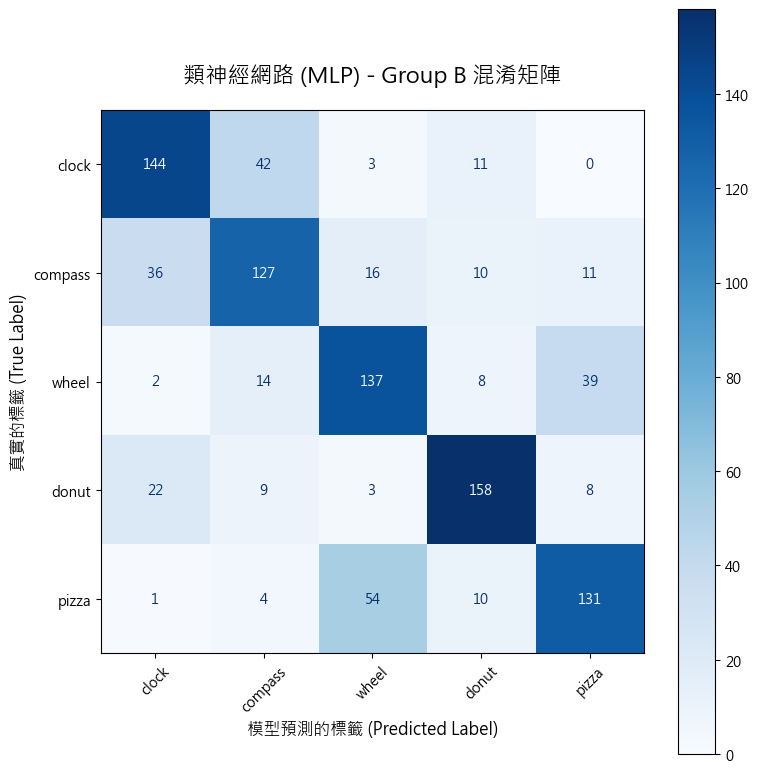

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

# 1. 單獨抓出我們想深入分析的模型 (MLP) 與資料集 (Group B)
print("🧠 正在重新訓練神經網路以分析 Group B (圓形系列)... 請稍候。")
mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(128, 64), 
        activation='relu', 
        solver='adam', 
        max_iter=500, 
        early_stopping=True, 
        random_state=42
    ))
])

# 進行訓練
mlp_pipeline.fit(X_train_B, y_train_B)

# 2. 讓模型進行預測，交出答卷
y_pred_B = mlp_pipeline.predict(X_test_B)

# 3. 計算並繪製混淆矩陣
cm = confusion_matrix(y_test_B, y_pred_B)

# 設定中文字體避免亂碼
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Microsoft JhengHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 畫圖設定
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=GROUP_B)

# cmap='Blues' 代表用藍色漸層顯示，數值越大顏色越深
disp.plot(cmap='Blues', ax=ax, values_format='d', xticks_rotation=45)

plt.title('類神經網路 (MLP) - Group B 混淆矩陣', fontsize=16, pad=20)
plt.xlabel('模型預測的標籤 (Predicted Label)', fontsize=12)
plt.ylabel('真實的標籤 (True Label)', fontsize=12)

plt.tight_layout()
plt.show()

🚀 開始測試不同資料量對模型的影響...

========== 處理 Group A (差異大) ==========
資料量  500 筆完成測試。
資料量 1500 筆完成測試。
資料量 2500 筆完成測試。
資料量 4000 筆完成測試。
----------------------------------------
========== 處理 Group B (差異小) ==========
資料量  500 筆完成測試。
資料量 1500 筆完成測試。
資料量 2500 筆完成測試。
資料量 4000 筆完成測試。
----------------------------------------


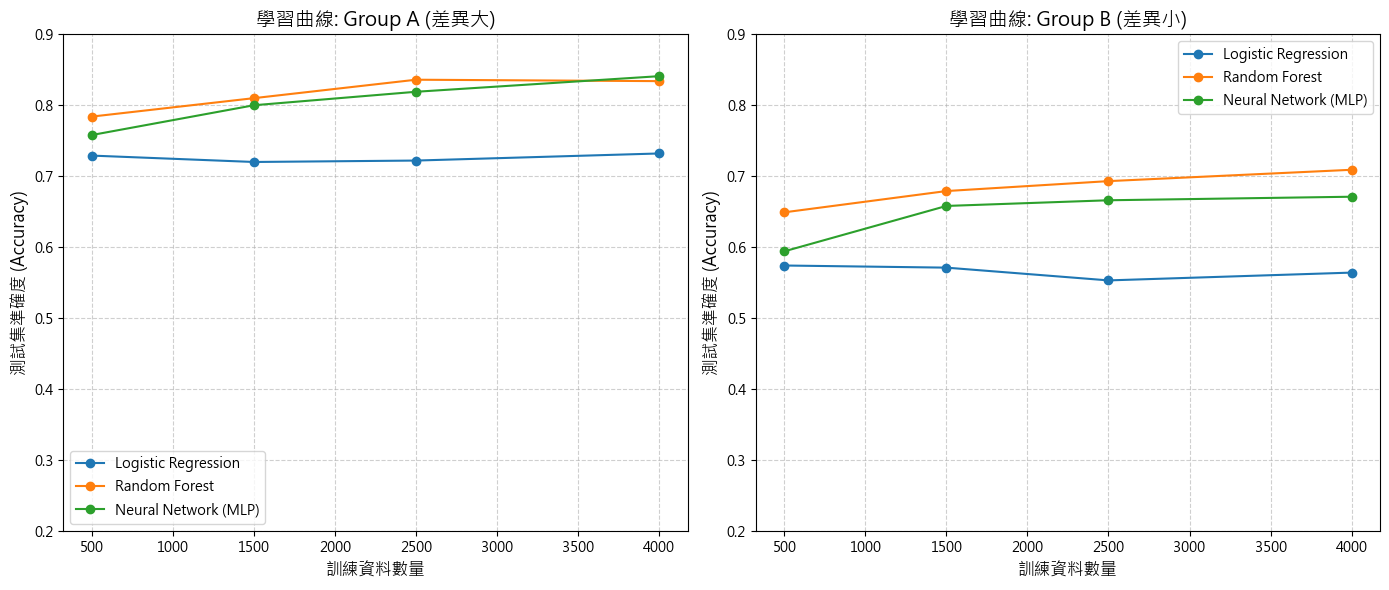

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import resample
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# 1. 準備模型與資料集
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, C=1.0),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu', solver='adam', max_iter=500, early_stopping=True, random_state=42)
}

datasets = {
    "Group A (差異大)": (X_train_A, X_test_A, y_train_A, y_test_A),
    "Group B (差異小)": (X_train_B, X_test_B, y_train_B, y_test_B)
}

# 2. 定義要測試的訓練資料量級距
# 假設完整訓練集有 4000 筆，我們測試 4 個階段
train_sizes = [500, 1500, 2500, len(X_train_A)]

# 準備記錄結果的結構
learning_curve_results = {group: {model: [] for model in models} for group in datasets}

print("🚀 開始測試不同資料量對模型的影響...\n")

# 3. 執行實驗
for group_name, (X_train, X_test, y_train, y_test) in datasets.items():
    print(f"========== 處理 {group_name} ==========")
    
    for size in train_sizes:
        # 使用 resample 進行分層抽樣，確保考卷範圍與比例正確
        X_sub, y_sub = resample(X_train, y_train, n_samples=size, random_state=42, stratify=y_train)
        
        for model_name, model in models.items():
            pipeline = Pipeline([('scaler', StandardScaler()), ('clf', model)])
            pipeline.fit(X_sub, y_sub)
            acc = pipeline.score(X_test, y_test)  # 永遠用同一份 X_test 評估
            learning_curve_results[group_name][model_name].append(acc)
            
        print(f"資料量 {size:4d} 筆完成測試。")
    print("-" * 40)

# 4. 將結果視覺化為折線圖
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Microsoft JhengHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
axes = {"Group A (差異大)": ax1, "Group B (差異小)": ax2}

for group_name, ax in axes.items():
    for model_name in models.keys():
        ax.plot(train_sizes, learning_curve_results[group_name][model_name], marker='o', label=model_name)
    
    ax.set_title(f"學習曲線: {group_name}", fontsize=14)
    ax.set_xlabel("訓練資料數量", fontsize=12)
    ax.set_ylabel("測試集準確度 (Accuracy)", fontsize=12)
    ax.set_ylim([0.2, 0.9])  # 固定 Y 軸範圍以便左右圖公平比較
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()